#Loan approval system

Accuracy: 98.24355971896955


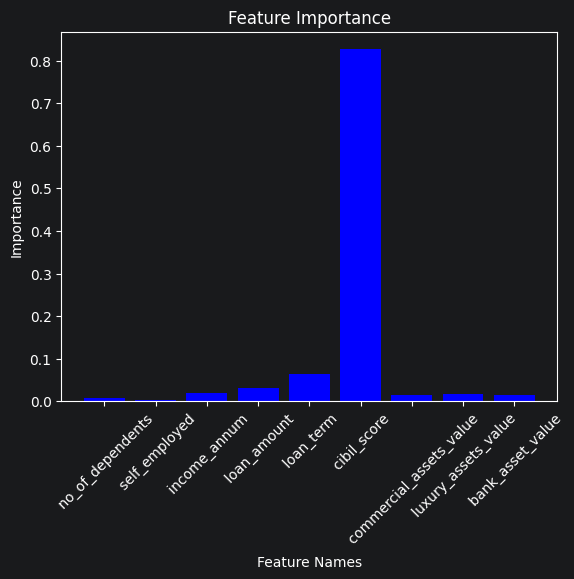

In [18]:
import pandas as pd
from setuptools.command.rotate import rotate
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"C:\Users\DELL\Downloads\loan_approval_dataset.csv")
le = LabelEncoder()
df[' self_employed'] = le.fit_transform(df[' self_employed'])
df.head()
X = df.drop([' loan_status', ' education', ' residential_assets_value', 'loan_id'], axis=1)
y = df[' loan_status']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred)*100)
imp = rf.feature_importances_
import matplotlib.pyplot as plt
plt.bar(X.columns, imp, color='blue')
plt.xlabel('Feature Names')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

In [27]:
sample_data = pd.DataFrame({
    ' no_of_dependents': [2, 0, 4],
    ' income_annum': [8000000, 4500000, 12000000],
    ' loan_amount': [2500000, 1000000, 4000000],
    ' loan_term': [10, 5, 15],
    ' cibil_score': [750, 400, 800],
    ' self_employed': [0, 1, 0],
    ' commercial_assets_value': [5000000, 1000000, 8000000],
    ' luxury_assets_value': [20000000, 5000000, 35000000],
    ' bank_asset_value': [7000000, 2000000, 10000000]
})

# Force same order as training data
sample_data = sample_data[X.columns]

predictions = rf.predict(sample_data)

print("Predictions for Sample Inputs:")
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: Loan Status - {pred}")

Predictions for Sample Inputs:
Sample 1: Loan Status -  Approved
Sample 2: Loan Status -  Rejected
Sample 3: Loan Status -  Approved


In [21]:
print(X.columns.tolist())

[' no_of_dependents', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']


In [22]:
print(sample_data.columns.tolist())


[' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' self_employed', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']


In [24]:
print(sample_data.columns.tolist())
print(X.columns.tolist())

[' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' self_employed', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']
[' no_of_dependents', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']
